In [9]:
import torch
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from rembg import remove

torch.set_num_threads(12)
torch.set_num_interop_threads(12)
torch.backends.mkldnn.enabled = True
device = "cpu"

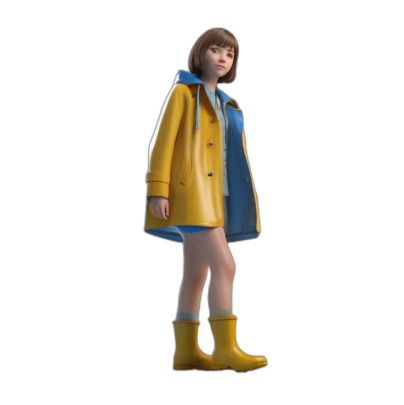

In [10]:

img = Image.open("master_character.png").convert("RGBA")

cut = remove(img).convert("RGBA")
cut_np = np.array(cut)

plt.figure(figsize=(5,5))
plt.imshow(cut)
plt.axis("off")
plt.show()

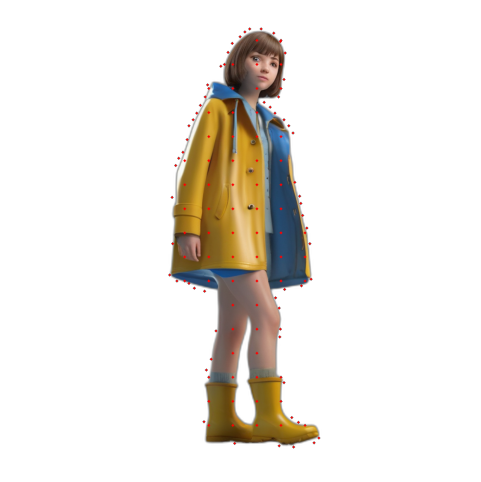

In [11]:
def build_mesh_points(alpha_mask, step=40, margin=10):
    h, w = alpha_mask.shape
    pts = []
    ys = np.arange(margin, h - margin, step)
    xs = np.arange(margin, w - margin, step)
    for y in ys:
        for x in xs:
            if alpha_mask[y, x] > 0:
                pts.append((int(x), int(y)))
    # add boundary points around the silhouette (helps stability)
    contours, _ = cv2.findContours((alpha_mask > 0).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        c = max(contours, key=cv2.contourArea)
        for i in range(0, len(c), max(1, len(c)//60)):
            x, y = c[i, 0]
            pts.append((int(x), int(y)))
    pts = list(dict.fromkeys(pts))  # dedupe
    return np.array(pts, dtype=np.float32)

alpha = cut_np[:, :, 3]
src_pts = build_mesh_points(alpha, step=40)

h, w = alpha.shape
vis = np.array(cut_np).copy()
for x, y in src_pts.astype(int):
    cv2.circle(vis, (x, y), 2, (255, 0, 0, 255), -1)

plt.figure(figsize=(6,6))
plt.imshow(vis)
plt.axis("off")
plt.show()

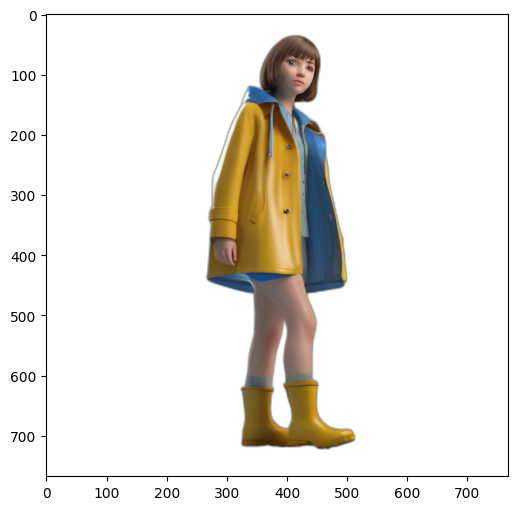

In [13]:
plt.figure(figsize=(6,6))
plt.imshow(cut)
plt.axis("on")
plt.show()

In [14]:
handles = np.array([
    (380, 150),  # head
    (330, 260),  # left shoulder
    (430, 260),  # right shoulder
    (350, 430),  # left hip
    (450, 430),  # right hip
    (420, 600),  # front knee
], dtype=np.float32)

In [ ]:
def apply_handle_delta(handles, deltas):
    return handles + np.array(deltas, dtype=np.float32)


# Pose 1 — Neutral
handles_1 = handles.copy()


# Pose 2 — Notice something (torso lean + slight head tilt)
handles_2 = apply_handle_delta(handles, [
    (-15, 10),   # head forward/down
    (-30, 20),   # L shoulder forward
    (-30, 20),   # R shoulder forward
    (-10, 5),    # L hip slight shift
    (-10, 5),    # R hip slight shift
    (-10, 20),   # knee mild bend
])


# Pose 3 — Bend down (clear articulation)
handles_3 = apply_handle_delta(handles, [
    (-40, 50),   # head down
    (-60, 70),   # L shoulder down
    (-60, 70),   # R shoulder down
    (-15, 20),   # L hip slight move
    (-15, 20),   # R hip slight move
    (-60, 120),  # knee strong bend
])


# Pose 4 — Step forward (weight shift)
handles_4 = apply_handle_delta(handles, [
    (15, -10),   # head slight lift
    (25, -5),    # L shoulder back
    (25, -5),    # R shoulder back
    (35, 10),    # L hip forward
    (35, 10),    # R hip forward
    (90, 70),    # knee forward step
])

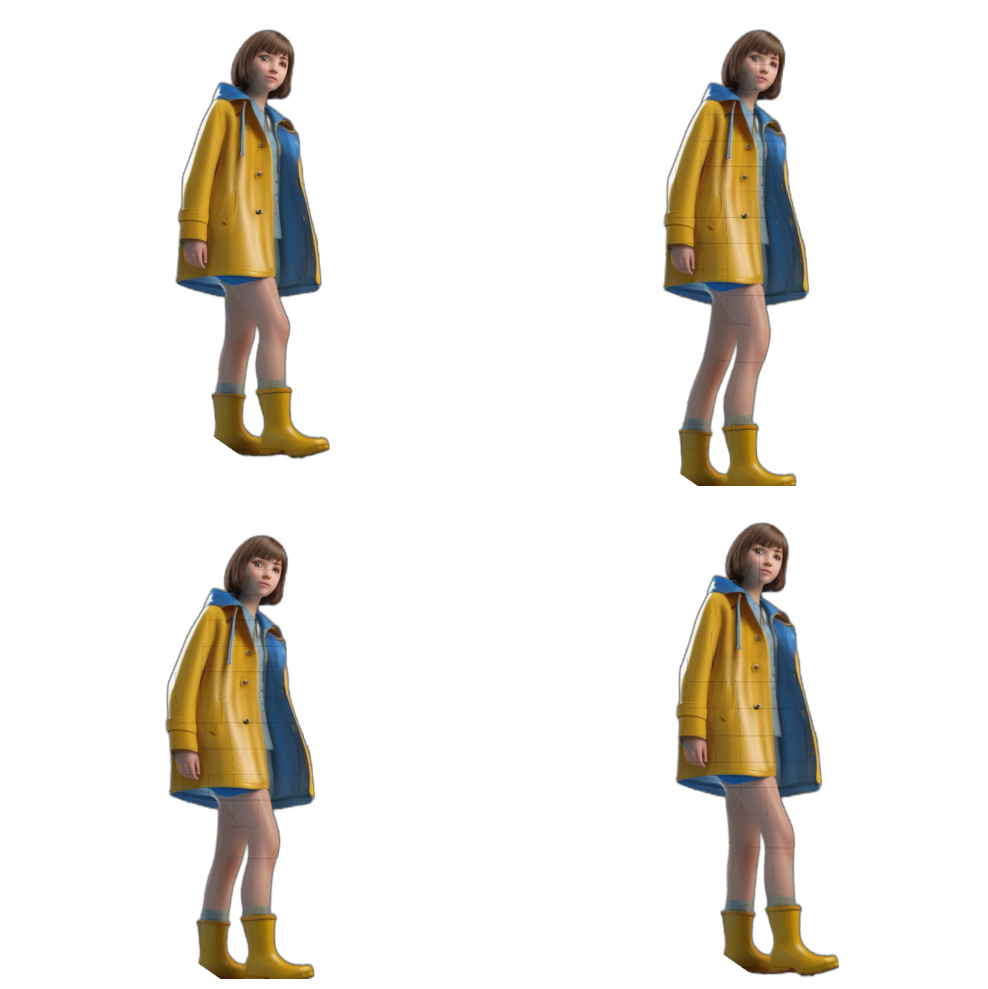

In [ ]:
def triangulate(w, h, points):
    subdiv = cv2.Subdiv2D((0, 0, w, h))
    for (x, y) in points:
        subdiv.insert((float(x), float(y)))
    tri = subdiv.getTriangleList()
    return tri.reshape(-1, 3, 2)


def tri_indices(triangles, points, eps=3.0):
    idx_tris = []
    pts = points
    for tri in triangles:
        inds = []
        ok = True
        for v in tri:
            d = np.linalg.norm(pts - v, axis=1)
            j = int(np.argmin(d))
            if d[j] > eps:
                ok = False
                break
            inds.append(j)
        if ok and len(set(inds)) == 3:
            idx_tris.append(tuple(inds))
    return idx_tris


def deform_points_with_handles(all_points, handles_src, handles_dst, sigma=60.0):
    P = all_points.copy()
    disp = np.zeros_like(P)

    for hs, hd in zip(handles_src, handles_dst):
        d = np.linalg.norm(P - hs, axis=1)
        w = np.exp(-(d**2) / (2 * sigma**2))
        disp += (hd - hs) * w[:, None]

    wsum = np.zeros((P.shape[0],), dtype=np.float32)
    for hs in handles_src:
        d = np.linalg.norm(P - hs, axis=1)
        wsum += np.exp(-(d**2) / (2 * sigma**2))

    disp /= np.maximum(wsum[:, None], 1e-6)
    return P + disp


def warp_piecewise(src_rgba, src_points, dst_points):
    h, w = src_rgba.shape[:2]
    triangles = triangulate(w, h, src_points)
    tris = tri_indices(triangles, src_points, eps=3.0)

    out = np.zeros_like(src_rgba)

    for (i1, i2, i3) in tris:
        t_src = np.float32([src_points[i1], src_points[i2], src_points[i3]])
        t_dst = np.float32([dst_points[i1], dst_points[i2], dst_points[i3]])

        r_src = cv2.boundingRect(t_src)
        r_dst = cv2.boundingRect(t_dst)

        x1, y1, w1, h1 = r_src
        x2, y2, w2, h2 = r_dst

        if w1 <= 0 or h1 <= 0 or w2 <= 0 or h2 <= 0:
            continue

        src_crop = src_rgba[y1:y1+h1, x1:x1+w1].copy()

        t_src_local = t_src - np.array([x1, y1], dtype=np.float32)
        t_dst_local = t_dst - np.array([x2, y2], dtype=np.float32)

        M = cv2.getAffineTransform(t_src_local, t_dst_local)

        warped = cv2.warpAffine(
            src_crop,
            M,
            (w2, h2),
            flags=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_CONSTANT,
            borderValue=(0, 0, 0, 0)
        )

        mask = np.zeros((h2, w2), dtype=np.uint8)
        cv2.fillConvexPoly(mask, np.int32(t_dst_local), 255)

        roi = out[y2:y2+h2, x2:x2+w2]

        # --- SAFE SHAPE ALIGNMENT ---
        h_min = min(roi.shape[0], warped.shape[0])
        w_min = min(roi.shape[1], warped.shape[1])

        roi = roi[:h_min, :w_min]
        warped = warped[:h_min, :w_min]
        mask_local = mask[:h_min, :w_min]

        alpha_w = (warped[:, :, 3] / 255.0) * (mask_local / 255.0)
        alpha_r = roi[:, :, 3] / 255.0

        for c in range(3):
            roi[:, :, c] = (
                roi[:, :, c] * (1 - alpha_w) +
                warped[:, :, c] * alpha_w
            ).astype(np.uint8)

        roi[:, :, 3] = np.clip(
            (alpha_r + alpha_w - alpha_r * alpha_w) * 255.0,
            0, 255
        ).astype(np.uint8)

        out[y2:y2+h_min, x2:x2+w_min] = roi

    return out


# --- BUILD POSES ---

dst1 = deform_points_with_handles(src_pts, handles, handles_1)
dst2 = deform_points_with_handles(src_pts, handles, handles_2)
dst3 = deform_points_with_handles(src_pts, handles, handles_3)
dst4 = deform_points_with_handles(src_pts, handles, handles_4)

w1 = warp_piecewise(cut_np, src_pts, dst1)
w2 = warp_piecewise(cut_np, src_pts, dst2)
w3 = warp_piecewise(cut_np, src_pts, dst3)
w4 = warp_piecewise(cut_np, src_pts, dst4)

poses = [Image.fromarray(x) for x in [w1, w2, w3, w4]]

fig, axs = plt.subplots(2, 2, figsize=(10,10))
for ax, im in zip(axs.flat, poses):
    ax.imshow(im)
    ax.axis("off")

plt.tight_layout()
plt.show()

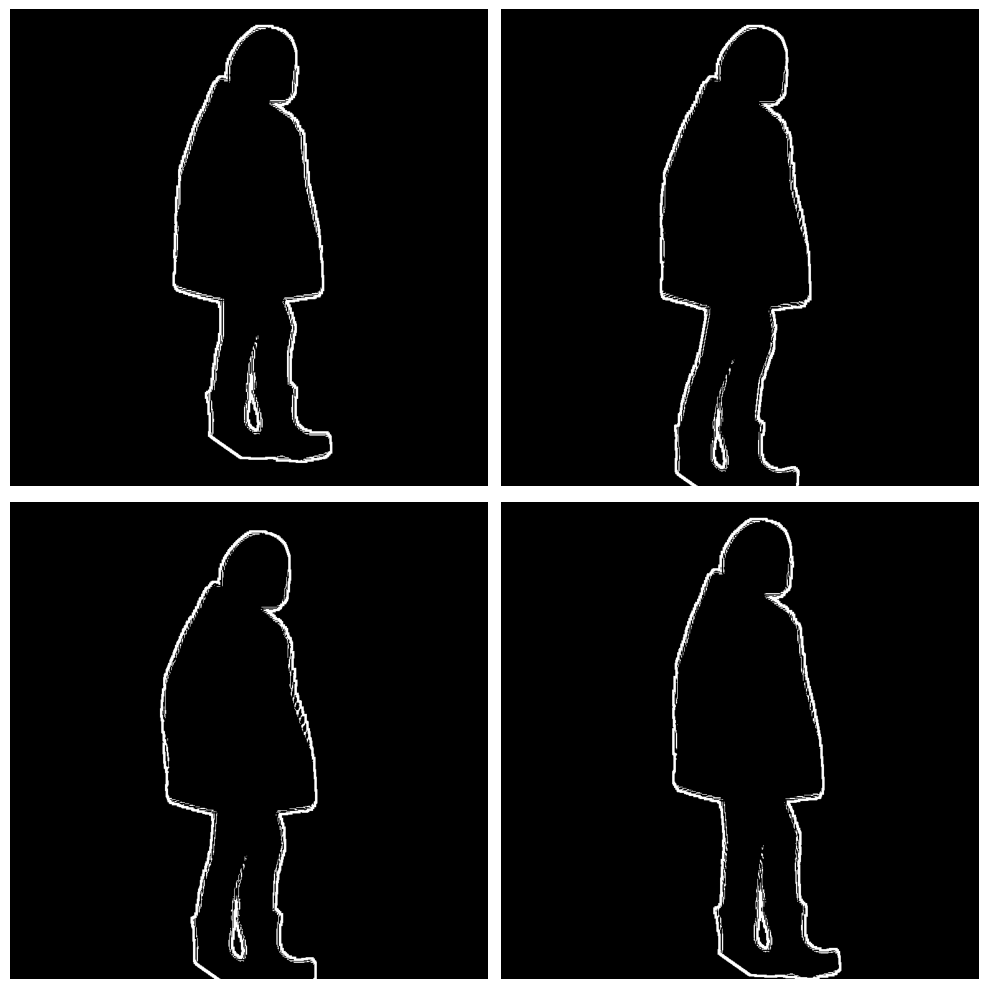

In [ ]:
def make_inpaint_mask(rgba, dilate=7):
    a = rgba[:, :, 3]
    # holes: transparent pixels that are near opaque pixels
    near = cv2.dilate((a > 0).astype(np.uint8), np.ones((dilate, dilate), np.uint8), iterations=1)
    holes = (near > 0) & (a == 0)
    mask = (holes.astype(np.uint8) * 255)
    return mask

masks = [make_inpaint_mask(np.array(im), dilate=9) for im in poses]

fig, axs = plt.subplots(2, 2, figsize=(10,10))
for ax, m in zip(axs.flat, masks):
    ax.imshow(m, cmap="gray")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [23]:
from diffusers import StableDiffusionInpaintPipeline

inpaint = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting",
    torch_dtype=torch.float32,
    safety_checker=None
).to(device)

inpaint.enable_attention_slicing()
inpaint.set_progress_bar_config(disable=False)

c:\Users\jacob\AppData\Local\Programs\Python\Python312\Lib\site-packages\diffusers\models\transformers\transformer_kandinsky.py:168: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)
c:\Users\jacob\AppData\Local\Programs\Python\Python312\Lib\site-packages\diffusers\models\transformers\transformer_kandinsky.py:272: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  @torch.autocast(device_type="cuda", dtype=torch.float32)


model_index.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

c:\Users\jacob\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\jacob\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\jacob\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\vae: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\jacob\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: C:\Users\jacob\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
An error occurred while trying to fetch C:\Users\jacob\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\unet: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\jacob\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
You have disabled the safety checker for <class 'di

In [26]:
PROMPT_INPAINT = (
    "same character, same style, smooth continuous coat and sleeves, consistent lighting, "
    "no changes to face or clothing, only fill missing pixels"
)
NEG_INPAINT = "different hair, different face, different clothes, extra limbs, deformed hands, artifacts"

def inpaint_pose(pose_rgba, mask_np, seed=42, steps=25, guidance=6.0):
    pose_rgb = pose_rgba.convert("RGB")
    mask_img = Image.fromarray(mask_np).convert("L")
    gen = torch.Generator(device).manual_seed(seed)
    out = inpaint(
        prompt=PROMPT_INPAINT,
        negative_prompt=NEG_INPAINT,
        image=pose_rgb,
        mask_image=mask_img,
        num_inference_steps=steps,
        guidance_scale=guidance,
        generator=gen
    ).images[0]
    return out
SEED = 42
filled = []
for i, (p, m) in enumerate(zip(poses, masks), 1):
    print(f"AI inpainting pose {i}/4 ...")
    filled_img = inpaint_pose(p, m, seed=SEED + i)
    filled.append(filled_img)
    plt.figure(figsize=(5,5))
    plt.imshow(filled_img)
    plt.axis("off")
    plt.show()

AI inpainting pose 1/4 ...


  0%|          | 0/25 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(10,10))
for ax, im in zip(axs.flat, filled):
    ax.imshow(im)
    ax.axis("off")
plt.tight_layout()
plt.show()